## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from itertools import compress 
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV


In [3]:
%matplotlib inline

In [4]:
dataset_location = "E:\GIT\Vitreus\data\datasets\dataset_A.xlsx"

In [5]:
df_raw = pd.read_excel(dataset_location)

In [6]:

y = df_raw['diagnostico_bin']

x = df_raw.drop(['diagnostico', 'diagnostico_bin','cod_exame', 'id_paciente'], axis=1)

x_norm_select = pd.DataFrame(preprocessing.normalize(df_raw.drop(['diagnostico', 'diagnostico_bin','cod_exame', 'id_paciente'], axis=1),axis=0),columns = [i+'_norm' for i in x.columns])


In [7]:
df = pd.concat([df_raw,x_norm_select],axis=1)

In [ ]:
# parametros = df.drop(columns=['id_paciente']).columns
# sns.pairplot(data=df[parametros],hue='diagnostico')

## Seleção de váriaveis

### analise normalizada

In [8]:
import pandas as pd
from numpy import sort
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.svm import SVC

#### matriz de correlação

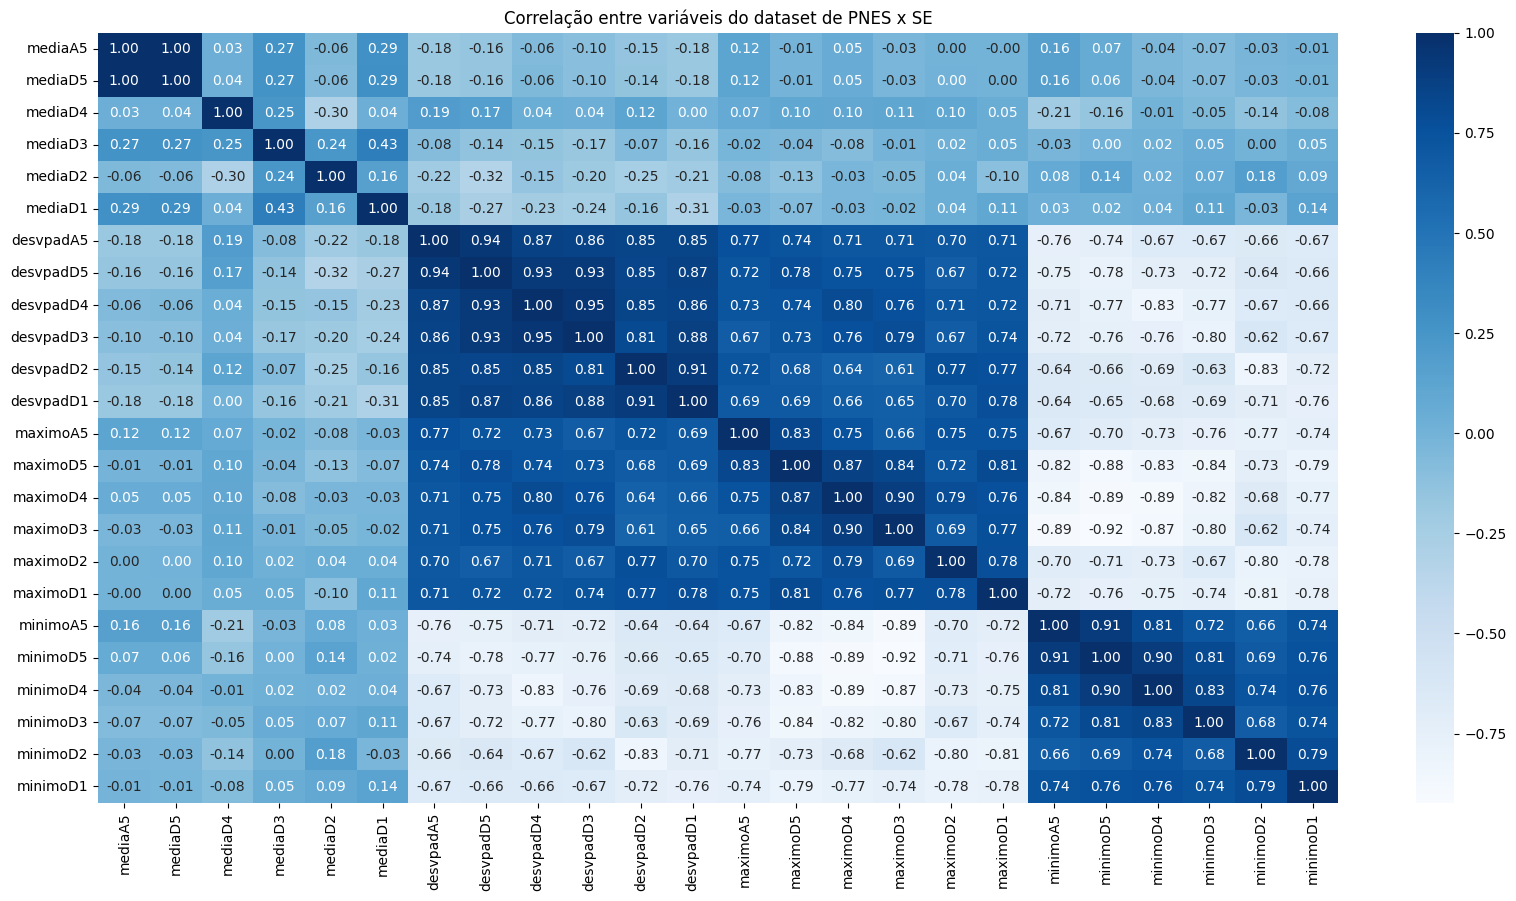

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 10))
sns.heatmap(x.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Blues')
plt.title('Correlação entre variáveis do dataset de PNES x SE')
plt.show()

In [11]:
x.corr().where(abs(x.corr()) > 0.5).stack().reset_index().rename(columns={0: 'correlation', 'level_0': 'feature1', 'level_1': 'feature2'}).query('feature1 != feature2').sort_values(by='correlation', ascending=False)

,feature1,feature2,correlation
1,mediaA5,mediaD5,0.999766
2,mediaD5,mediaA5,0.999766
64,desvpadD3,desvpadD4,0.950453
47,desvpadD4,desvpadD3,0.950453
9,desvpadA5,desvpadD5,0.942056
...,...,...,...
182,maximoD3,minimoA5,-0.893292
165,maximoD4,minimoD5,-0.894023
250,minimoD5,maximoD4,-0.894023
183,maximoD3,minimoD5,-0.922181


In [239]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt 

def plot_coefficients(classifier, feature_names, top_features=20):
    coef = classifier.coef_
    top_positive_coefficients = np.argsort(coef)[-top_features:]
    top_negative_coefficients = np.argsort(coef)[:top_features]
    top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])
    # create plot
    plt.figure(figsize=(15, 5))
    colors = ['red' if c < 0 else 'blue' for c in coef[top_coefficients]]
    plt.bar(np.arange(2 * top_features), coef[top_coefficients], color=colors)
    feature_names = np.array(feature_names)
    plt.xticks(np.arange(1, 1 + 2 * top_features), feature_names[top_coefficients], rotation=60, ha='right')
    plt.show()
    cv = CountVectorizer()
    cv.fit(x_norm_select)
    print (len(cv.vocabulary_))
    print (cv.get_feature_names())
    X_train = cv.transform(x_norm_select)

    svm = LinearSVC()
    svm.fit(X_train, target)
    plot_coefficients(svm, cv.get_feature_names())

#### treino sem nenhum tratamento de features

In [210]:
import numpy as np
from collections import Counter
roc_auc_list = []

# Loop para rodar 30 vezes
for i in range(100):
    # Separa os dados em treino e teste (33% para teste)
    X_train, X_test, y_train, y_test = train_test_split(
        x_norm_select, y, test_size=0.33, random_state=i
    )

    # Define o balanceamento das classes para o SVM
    balanceamento = {1: 1.8, 0: 1}

    # Cria o classificador SVM com kernel RBF e balanceamento de classes
    svc = svm.SVC(kernel='rbf', class_weight=balanceamento)

    # Treina o modelo SVM
    svc.fit(X_train, y_train)

    # Obtém os scores de decisão do SVM para o conjunto de teste
    y_scores = svc.decision_function(X_test)

    # Calcula a métrica ROC AUC usando os scores de decisão
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_auc_list.append(roc_auc)

# Calcula menor, maior e o valor mais frequente (moda)
menor = np.min(roc_auc_list)
maior = np.max(roc_auc_list)
mais_frequente = Counter(np.round(roc_auc_list, 4)).most_common(1)[0][0]

print(f"Menor ROC AUC: {menor:.4f}")
print(f"Maior ROC AUC: {maior:.4f}")
print(f"Valor mais frequente de ROC AUC: {mais_frequente:.4f}")
print(f"media ROC AUC: {np.mean(roc_auc_list):.4f}")

Menor ROC AUC: 0.4701
Maior ROC AUC: 0.9279
Valor mais frequente de ROC AUC: 0.7039
media ROC AUC: 0.7350


#### treino selecionando features da permutação de importancia

Text(0.5, 0, 'Permutation Importance')

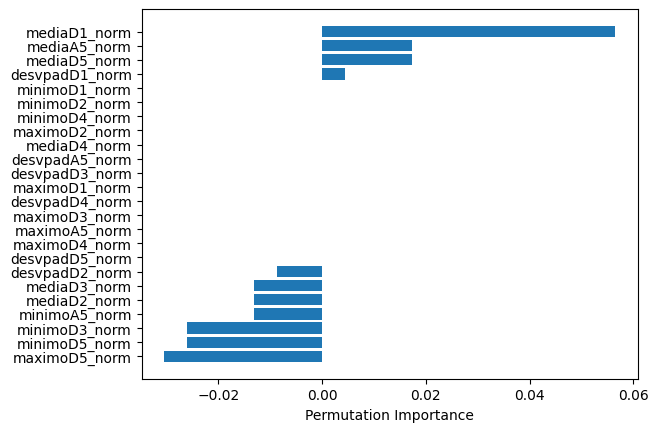

In [49]:
perm_importance = permutation_importance(svc, X_test, y_test)

features = np.array(list(x_norm_select.columns))

sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

In [65]:
features_filtradas = list(compress(features  , ((perm_importance.importances_mean > 0.01)  | (perm_importance.importances_mean < -0.01))))
features_filtradas = [str(f) for f in features_filtradas]
print(features_filtradas)

['mediaA5_norm', 'mediaD5_norm', 'mediaD3_norm', 'mediaD2_norm', 'mediaD1_norm', 'maximoD5_norm', 'minimoA5_norm', 'minimoD5_norm', 'minimoD3_norm']


In [230]:
import numpy as np
from collections import Counter
roc_auc_list = []

# Loop para rodar 30 vezes
for i in range(100):
    # Separa os dados em treino e teste (33% para teste)
    X_train, X_test, y_train, y_test = train_test_split(
        x_norm_select[features_filtradas], y, test_size=0.33)

    # Define o balanceamento das classes para o SVM
    balanceamento = {1: 1.8, 0: 1}

    # Cria o classificador SVM com kernel RBF e balanceamento de classes
    svc = svm.SVC(kernel='rbf', class_weight=balanceamento)

    # Treina o modelo SVM
    svc.fit(X_train, y_train)

    # Obtém os scores de decisão do SVM para o conjunto de teste
    y_scores = svc.decision_function(X_test)

    # Calcula a métrica ROC AUC usando os scores de decisão
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_auc_list.append(roc_auc)

# Calcula menor, maior e o valor mais frequente (moda)
menor = np.min(roc_auc_list)
maior = np.max(roc_auc_list)
mais_frequente = Counter(np.round(roc_auc_list, 4)).most_common(1)[0][0]

print(f"Menor ROC AUC: {menor:.4f}")
print(f"Maior ROC AUC: {maior:.4f}")
print(f"Valor mais frequente de ROC AUC: {mais_frequente:.4f}")
print(f"media ROC AUC: {np.mean(roc_auc_list):.4f}")

Menor ROC AUC: 0.5556
Maior ROC AUC: 0.9534
Valor mais frequente de ROC AUC: 0.7718
media ROC AUC: 0.7697


#### treino selecionando featuires usando step foward

In [153]:
sfs = SequentialFeatureSelector(estimator=svc, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)

# Selected feature indices
selected_features_fast_foward = list(sfs.get_support(indices=True))
selected_features_fast_foward_name = x_norm_select.iloc[:,selected_features_fast_foward].columns

x_norm_select.iloc[:,selected_features_fast_foward], selected_features_fast_foward_name

(     mediaA5_norm  mediaD2_norm  mediaD1_norm  desvpadD4_norm  desvpadD3_norm
 0       -0.269242      0.147758     -0.045490        0.051228        0.081633
 1       -0.350085     -0.044407     -0.284227        0.079110        0.061344
 2        0.153520     -0.081330     -0.087806        0.075560        0.114386
 3       -0.207965     -0.177942     -0.237808        0.052937        0.069025
 4        0.029539     -0.151049     -0.009161        0.096032        0.105084
 ..            ...           ...           ...             ...             ...
 134     -0.000557     -0.015167     -0.003890        0.079666        0.118343
 135      0.003066     -0.005619     -0.027072        0.020620        0.027510
 136     -0.059809     -0.006657     -0.029956        0.125700        0.134433
 137     -0.001196      0.004998     -0.030318        0.008203        0.006215
 138     -0.054715     -0.028629     -0.096315        0.056557        0.077393
 
 [139 rows x 5 columns],
 Index(['mediaA5_norm', '

In [222]:
roc_auc_list = []

# Loop para rodar 30 vezes
for i in range(100):
    # Separa os dados em treino e teste (33% para teste)
    X_train, X_test, y_train, y_test = train_test_split(
        x_norm_select[selected_features_fast_foward_name], y, test_size=0.33)

    # Define o balanceamento das classes para o SVM
    balanceamento = {1: 1.8, 0: 1}

    # Cria o classificador SVM com kernel RBF e balanceamento de classes
    svc = svm.SVC(kernel='rbf', class_weight=balanceamento)

    # Treina o modelo SVM
    svc.fit(X_train, y_train)

    # Obtém os scores de decisão do SVM para o conjunto de teste
    y_scores = svc.decision_function(X_test)

    # Calcula a métrica ROC AUC usando os scores de decisão
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_auc_list.append(roc_auc)

# Calcula menor, maior e o valor mais frequente (moda)
menor = np.min(roc_auc_list)
maior = np.max(roc_auc_list)
mais_frequente = Counter(np.round(roc_auc_list, 4)).most_common(1)[0][0]

print(f"Menor ROC AUC: {menor:.4f}")
print(f"Maior ROC AUC: {maior:.4f}")
print(f"Valor mais frequente de ROC AUC: {mais_frequente:.4f}")
print(f"media ROC AUC: {np.mean(roc_auc_list):.4f}")

Menor ROC AUC: 0.6225
Maior ROC AUC: 1.0000
Valor mais frequente de ROC AUC: 0.7333
media ROC AUC: 0.7970


### analise não normalizada 

In [34]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)
balanceamento = {1: 1.8, 0: 1}

svc = svm.SVC(kernel='poly', class_weight=balanceamento)
svc.fit(X_train, y_train)
from sklearn.metrics import roc_auc_score
y_scores = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test, y_scores)
print("ROC AUC:", roc_auc)

SVC(class_weight={0: 1, 1: 1.8}, kernel='poly')

In [ ]:


perm_importance = permutation_importance(svc, X_test, y_test)

features = np.array(list(x_norm_select.columns))

sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

In [12]:
sfs = SequentialFeatureSelector(estimator=svc, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)

# Selected feature indices
selected_features = list(sfs.get_support(indices=True))

x.iloc[:,selected_features], x.iloc[:,selected_features].columns

(          mediaD5    mediaD4    mediaD3     mediaD1    desvpadD1
 0   -1.180792e-13 -54.751338  39.329875  -40.954451   666.281552
 1   -1.507061e-13 -37.706197 -37.293552 -255.886461   699.744054
 2    6.902339e-14 -68.429380  11.218299  -79.050710  1008.932371
 3   -9.217408e-14  -1.380568 -72.373312 -214.095893   662.471105
 4    1.283355e-14 -55.112087  28.521332   -8.247332  1232.246285
 ..            ...        ...        ...         ...          ...
 134 -2.402025e-16   1.187820   1.517382   -3.501996   626.608116
 135  1.203747e-15  -9.840589  -1.470042  -24.372327   305.657247
 136 -2.649129e-14  13.908952  -4.970163  -26.968734   433.856077
 137 -5.427786e-16   2.051034  -5.564086  -27.294977    72.772628
 138 -2.341496e-14  32.436031   7.872192  -86.711260   455.270811
 
 [139 rows x 5 columns],
 Index(['mediaD5', 'mediaD4', 'mediaD3', 'mediaD1', 'desvpadD1'], dtype='object'))

## Otimização de Hiperparametros

In [ ]:
gamma_range = np.logsace(-8, 1, 10)
C_range = np.logspace(-1,7,10)
parameters = {'kernel':('linear', 'rbf','poly','sigmoid'),
              'cache_size':[2000],
              'class_weight':[{1:2,0:1},{1:3,0:1},{1:3.5,0:1}],
              'gamma': gamma_range,
              'C':C_range}

In [15]:

gamma_range

array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01,
       1.e+00, 1.e+01])

In [16]:
#dataset A
svc = svm.SVC()
clf = GridSearchCV(svc, parameters)
x_norm = preprocessing.normalize(df_raw.drop(['diagnostico', 'diagnostico_bin','cod_exame', 'id_paciente'], axis=1),axis=0)
clf.fit(x_norm, y)
result = pd.DataFrame(clf.cv_results_)
result[result.rank_test_score == 1]['params'].values , result[result.rank_test_score == 1]['mean_test_score'].values

(array([{'C': 0.774263682681127, 'cache_size': 2000, 'class_weight': {1: 2, 0: 1}, 'gamma': 10.0, 'kernel': 'rbf'}],
       dtype=object),
 array([0.79100529]))

In [17]:
#dataset B
svc = svm.SVC()
clf = GridSearchCV(svc, parameters)
clf.fit(x_norm_select, y)
result = pd.DataFrame(clf.cv_results_)
result[result.rank_test_score == 1]['params'].values , result[result.rank_test_score == 1]['mean_test_score'].values

(array([{'C': 0.774263682681127, 'cache_size': 2000, 'class_weight': {1: 2, 0: 1}, 'gamma': 10.0, 'kernel': 'rbf'}],
       dtype=object),
 array([0.79100529]))

In [18]:
result.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_cache_size,param_class_weight,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
157,0.0016,4.901156e-04,0.002601,8.004433e-04,0.774264,2000,"{1: 2, 0: 1}",10.0,rbf,"{'C': 0.774263682681127, 'cache_size': 2000, '...",0.892857,0.857143,0.750000,0.714286,0.740741,0.791005,0.070487,1
269,0.0016,4.899209e-04,0.001400,4.899014e-04,5.994843,2000,"{1: 2, 0: 1}",0.1,rbf,"{'C': 5.994842503189409, 'cache_size': 2000, '...",0.821429,0.892857,0.714286,0.750000,0.740741,0.783862,0.065020,2
136,0.0010,9.536743e-08,0.001000,4.422006e-07,0.774264,2000,"{1: 2, 0: 1}",0.0001,linear,"{'C': 0.774263682681127, 'cache_size': 2000, '...",0.821429,0.892857,0.714286,0.750000,0.740741,0.783862,0.065020,2
128,0.0012,4.000664e-04,0.001000,4.422006e-07,0.774264,2000,"{1: 2, 0: 1}",0.000001,linear,"{'C': 0.774263682681127, 'cache_size': 2000, '...",0.821429,0.892857,0.714286,0.750000,0.740741,0.783862,0.065020,2
140,0.0014,4.900182e-04,0.000600,4.899792e-04,0.774264,2000,"{1: 2, 0: 1}",0.001,linear,"{'C': 0.774263682681127, 'cache_size': 2000, '...",0.821429,0.892857,0.714286,0.750000,0.740741,0.783862,0.065020,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,0.0014,4.900960e-04,0.000600,4.900182e-04,166810.05372,2000,"{1: 3.5, 0: 1}",0.0,poly,"{'C': 166810.05372000558, 'cache_size': 2000, ...",0.285714,0.285714,0.285714,0.250000,0.259259,0.273280,0.015507,836
925,0.0014,4.899598e-04,0.003601,8.001328e-04,166810.05372,2000,"{1: 3.5, 0: 1}",0.0,rbf,"{'C': 166810.05372000558, 'cache_size': 2000, ...",0.285714,0.285714,0.285714,0.250000,0.259259,0.273280,0.015507,836
934,0.0014,4.903493e-04,0.000800,4.000902e-04,166810.05372,2000,"{1: 3.5, 0: 1}",0.00001,poly,"{'C': 166810.05372000558, 'cache_size': 2000, ...",0.285714,0.285714,0.285714,0.250000,0.259259,0.273280,0.015507,836
119,0.0014,4.899404e-04,0.001000,2.336015e-07,0.1,2000,"{1: 3.5, 0: 1}",10.0,sigmoid,"{'C': 0.1, 'cache_size': 2000, 'class_weight':...",0.285714,0.250000,0.285714,0.250000,0.259259,0.266138,0.016338,1199


In [19]:
clf.best_params_

{'C': 0.774263682681127,
 'cache_size': 2000,
 'class_weight': {1: 2, 0: 1},
 'gamma': 10.0,
 'kernel': 'rbf'}